# **Customer Satisfaction Prediction**

## Tools Used  

- **Python** – Programming language used for data analysis and model building  
- **Pandas** – Data cleaning and manipulation  
- **NumPy** – Numerical computations  
- **Matplotlib & Seaborn** – Data visualization and exploratory data analysis  
- **Scikit-learn** – Machine learning models (Logistic Regression, Random Forest) and preprocessing  
- **Jupyter Notebook / Google Colab** – Development environment  

## Problem Statement  

The project aims to analyze customer support ticket data to understand patterns in customer issues and service performance.  
It attempts to derive insights about customer service efficiency and satisfaction levels based on ticket trends and categories.  
However, identifying meaningful patterns can be challenging due to unstructured data and varying ticket types.  

In [14]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

## Load Dataset  

The dataset contains customer support ticket details such as ticket type, status, priority, response time, and customer satisfaction rating.  
It is used to analyze customer service performance and understand patterns in customer issues and resolution efficiency.  

In [15]:
df = pd.read_csv("/content/customer_support_tickets.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [16]:
# Convert date column to datetime
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])

# Handle missing satisfaction ratings
df = df.dropna(subset=['Customer Satisfaction Rating'])

# Remove unnecessary columns
df = df.drop(['Customer Name','Customer Email','Ticket Description','Resolution'], axis=1)

In [17]:
# Convert date into numeric features for ML models
df['purchase_year'] = df['Date of Purchase'].dt.year
df['purchase_month'] = df['Date of Purchase'].dt.month
df['purchase_day'] = df['Date of Purchase'].dt.day

# Remove original datetime column
df = df.drop('Date of Purchase', axis=1)

## **Dataset Overview & Preprocessing**
The dataset is preprocessed by converting the purchase date into a proper datetime format and extracting useful features like year, month, and day.  
Missing values in customer satisfaction ratings are handled, and irrelevant columns are removed to improve model performance and data quality.  

## **Exploratory Data Analysis (EDA)**

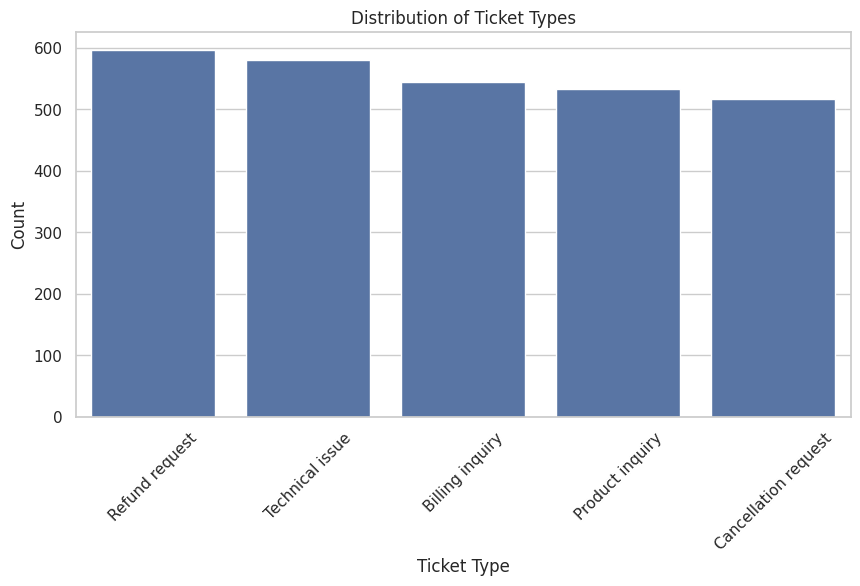

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Ticket Type',
    order=df['Ticket Type'].value_counts().index
)

plt.title('Distribution of Ticket Types')
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

# Distribution of Ticket Types

## What this chart shows

This bar chart displays the frequency of different ticket types submitted by customers. Each bar represents the total number of tickets belonging to a specific category, helping identify the most common issues reported to the support team.

## Key observations

- Certain ticket types occur significantly more frequently than others.
- High-volume categories indicate the most common customer concerns.
- Some ticket types appear less frequently, suggesting specialized or less common issues.
- The distribution highlights where support teams spend most of their effort.
- Large differences between categories may indicate recurring operational or product-related problems.

## Business insight

Analyzing ticket type distribution helps organizations understand customer pain points and prioritize resources effectively. Frequently occurring ticket categories often represent areas where process improvements, product enhancements, or additional customer education may be required.

## Actionable recommendation

- Prioritize resolution and prevention strategies for the most common ticket types.
- Create self-service resources such as FAQs and knowledge base articles for recurring issues.
- Allocate support staff according to ticket volume across categories.
- Investigate root causes behind high-frequency ticket types to reduce future support requests.

## Key takeaway

Ticket requests are not evenly distributed across categories. A small number of ticket types typically account for the majority of support requests, making them critical areas for operational improvement and customer experience enhancement.

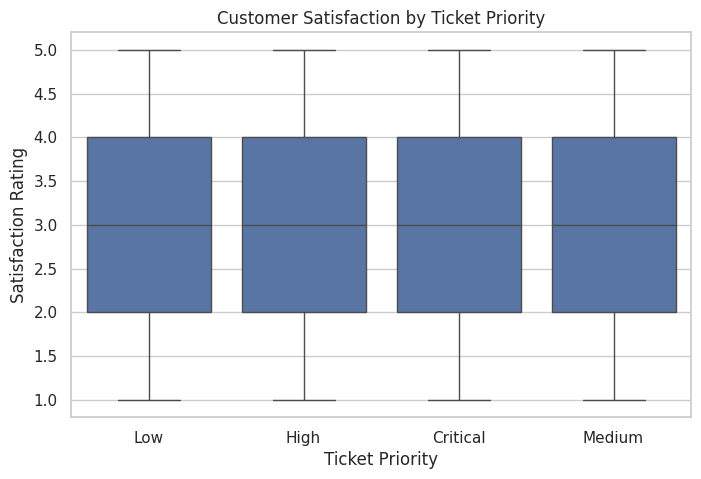

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Ticket Priority',
    y='Customer Satisfaction Rating'
)

plt.title('Customer Satisfaction by Ticket Priority')
plt.xlabel('Ticket Priority')
plt.ylabel('Satisfaction Rating')

plt.show()

# Customer Satisfaction by Ticket Priority

## What this chart shows

This box plot compares customer satisfaction ratings across different ticket priority levels.

## Key observations

- Satisfaction levels vary across priority categories.
- Some priorities may have higher median satisfaction scores.
- Wider spreads indicate inconsistent customer experiences.
- Outliers highlight unusually high or low satisfaction ratings.

## Business insight

Analyzing satisfaction across priority levels helps determine whether urgent cases are being handled effectively.

## Actionable recommendation

- Improve response times for priority levels with lower satisfaction.
- Investigate causes of negative customer experiences.
- Standardize support quality across all priorities.

## Key takeaway

Customer satisfaction is influenced by ticket priority, making it an important factor in service quality management.

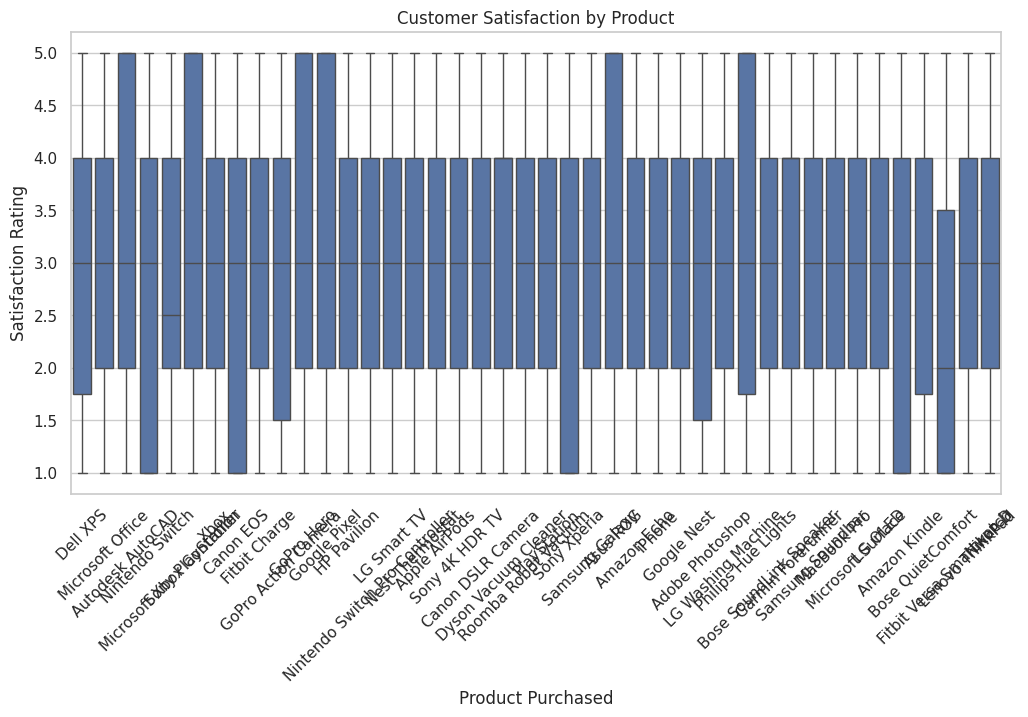

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Product Purchased',
    y='Customer Satisfaction Rating'
)

plt.title('Customer Satisfaction by Product')
plt.xlabel('Product Purchased')
plt.ylabel('Satisfaction Rating')
plt.xticks(rotation=45)

plt.show()

# Customer Satisfaction by Product

## What this chart shows

This chart compares customer satisfaction ratings across different products.

## Key observations

- Some products consistently receive higher satisfaction ratings.
- Products with lower ratings may indicate quality or support issues.
- Variability differs across products.
- Outliers may represent exceptional customer experiences.

## Business insight

Product-level satisfaction analysis helps identify products requiring additional support or quality improvements.

## Actionable recommendation

- Investigate products with consistently lower ratings.
- Improve customer support for problematic products.
- Use customer feedback to guide product enhancements.

## Key takeaway

Customer satisfaction varies across products, providing valuable insights for product improvement and customer retention.

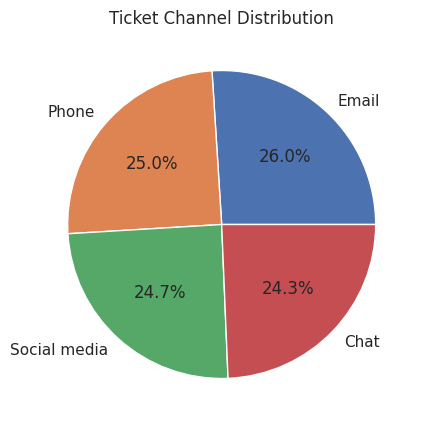

In [23]:
plt.figure(figsize=(8,5))

df['Ticket Channel'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Ticket Channel Distribution')
plt.ylabel('')

plt.show()

# Ticket Channel Distribution

## What this chart shows

This pie chart illustrates the proportion of customer support tickets received through different communication channels.

## Key observations

- Some channels are used significantly more than others.
- Customer preferences can be identified through channel usage patterns.
- A dominant channel may require additional staffing and support resources.
- Smaller channels may still serve niche customer segments.

## Business insight

Understanding channel preferences helps optimize customer support operations and resource allocation.

## Actionable recommendation

- Allocate more support resources to highly utilized channels.
- Improve service quality across all communication channels.
- Encourage use of efficient digital channels where appropriate.

## Key takeaway

Customers tend to favor specific support channels, making channel optimization an important aspect of customer service strategy.

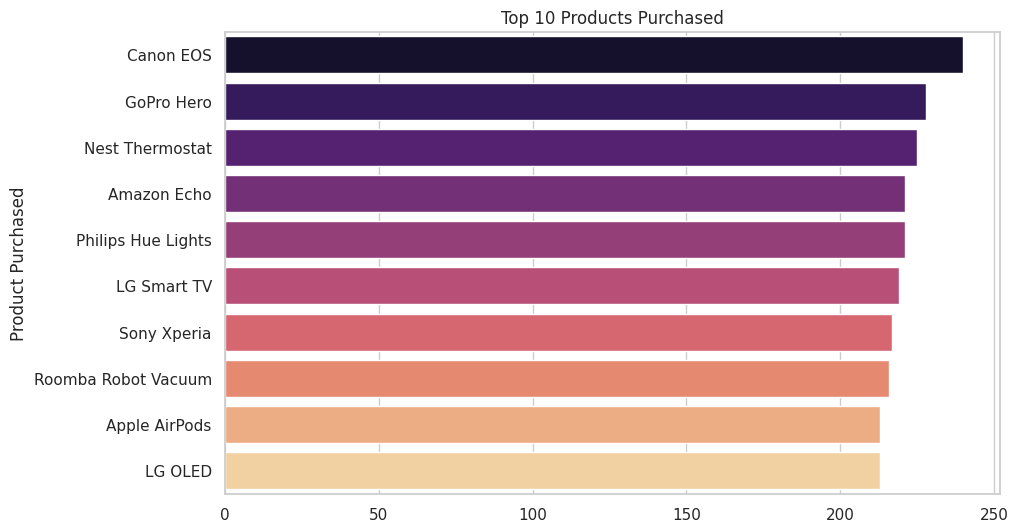

In [ ]:
top_products = df['Product Purchased'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Products Purchased")

plt.show()

## Top 10 Products Purchased  

### What this chart shows  

This chart displays the top 10 most frequently purchased products using a horizontal bar plot.  
It shows the number of times each product was purchased, highlighting the most popular items among customers.  

### Key observations  

A few products have significantly higher purchase counts than others  
The distribution is uneven, with certain products dominating sales  
Lower-ranked products still contribute but at a much smaller scale  

### Business insight  

The chart helps identify best-selling products and customer preferences.  
Popular products may indicate higher demand, better quality, or effective marketing strategies.  

### Actionable recommendation  

Focus on promoting and maintaining stock for high-demand products  
Analyze why top products perform well and replicate strategies for others  
Consider improving or repositioning low-performing products  

### Key takeaway  

Sales are concentrated among a few top-performing products, emphasizing the importance of focusing on high-demand items to maximize revenue and customer satisfaction.  

In [ ]:
# Encode categorical variables into numerical values
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Define independent variables (features)
X = df.drop(['Customer Satisfaction Rating','Ticket ID'], axis=1)

# Define dependent variable (target)
y = df['Customer Satisfaction Rating']

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
# Standardize numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# STEP 1: Remove rows where target has NaN
df = df.dropna(subset=['Customer Satisfaction Rating'])

# STEP 2: Define X and y AFTER cleaning
X = df.drop('Customer Satisfaction Rating', axis=1)
y = df['Customer Satisfaction Rating']

# STEP 3: Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# STEP 4: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 5: Train model (your code)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.2292418772563177
              precision    recall  f1-score   support

         1.0       0.21      0.20      0.21       109
         2.0       0.25      0.21      0.23       117
         3.0       0.25      0.35      0.29       112
         4.0       0.24      0.22      0.23       108
         5.0       0.18      0.16      0.17       108

    accuracy                           0.23       554
   macro avg       0.23      0.23      0.23       554
weighted avg       0.23      0.23      0.23       554



In [ ]:
# STEP 1: Handle missing target values
df = df.dropna(subset=['Customer Satisfaction Rating'])

# STEP 2: Define features and target
X = df.drop('Customer Satisfaction Rating', axis=1)
y = df['Customer Satisfaction Rating']

# STEP 3: Convert categorical variables to numeric
X = pd.get_dummies(X, drop_first=True)

# STEP 4: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 5: Scale features (IMPORTANT for Logistic Regression)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# STEP 6: Train Logistic Regression model (clean - no warnings)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# STEP 7: Predictions
lr_pred = lr.predict(X_test)

# STEP 8: Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.22563176895306858
              precision    recall  f1-score   support

         1.0       0.16      0.15      0.15       109
         2.0       0.24      0.24      0.24       117
         3.0       0.26      0.33      0.29       112
         4.0       0.25      0.26      0.26       108
         5.0       0.20      0.15      0.17       108

    accuracy                           0.23       554
   macro avg       0.22      0.22      0.22       554
weighted avg       0.22      0.23      0.22       554



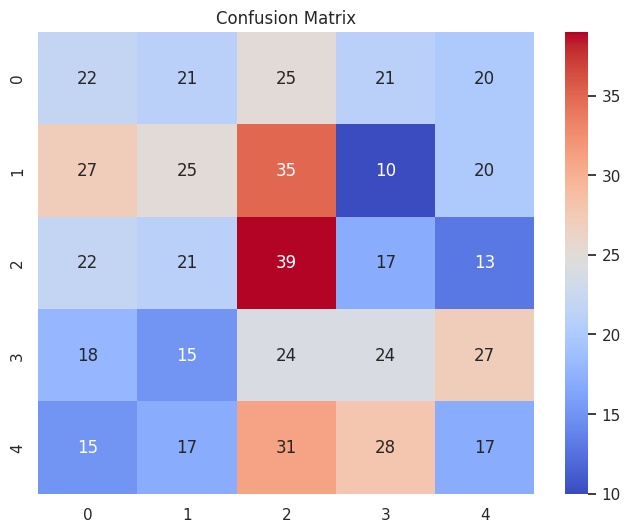

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="coolwarm",
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

The Confusion Matrix is used for visual representation of the performance of the machine learning model in predicting customer satisfaction ratings. The matrix represents the number of correct or incorrect predictions for each category of customer satisfaction ratings. The diagonal line represents the correct predictions, while the rest of the values denote incorrect predictions.

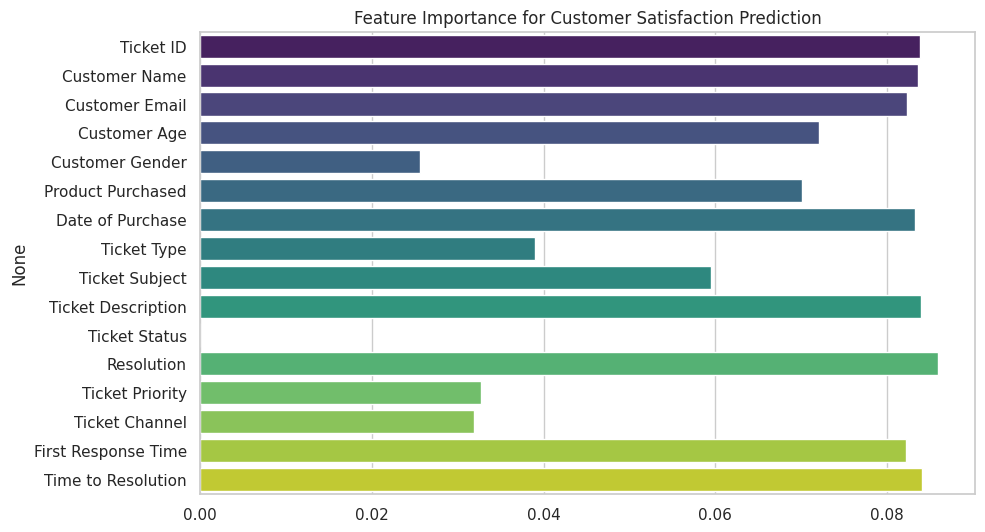

In [ ]:
# Extract feature importance from Random Forest model
importance = rf.feature_importances_

# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance,
    y=X.columns,
    hue=X.columns,
    palette="viridis",
    legend=False
)

plt.title("Feature Importance for Customer Satisfaction Prediction")

plt.show()


**Feature Importance for Customer Satisfaction Prediction**

This graph shows the relative importance of different features used by the machine learning model to predict customer satisfaction ratings. From the chart, **First Response Time and Time to Resolution** have the highest importance, indicating that faster support responses and quicker problem resolution strongly influence customer satisfaction. Features such as **Product Purchased, Customer Age, and Ticket Subject** also contribute moderately to the prediction, while variables like **Customer Gender and purchase year** have comparatively lower impact. Overall, the model suggests that **service efficiency and response time are the most critical factors affecting customer satisfaction.**





## Conclusion  

The objective of this project was to analyze customer support ticket data and derive meaningful insights regarding customer service performance and satisfaction levels. Through exploratory data analysis and visualization, it was observed that customer satisfaction varies across different service interactions, indicating a mixed customer experience. Customers utilize multiple support channels such as email, phone, chat, and social media, with certain products generating a higher volume of support requests.  

Machine learning models, including Random Forest and Logistic Regression, were applied to predict customer satisfaction based on various features. The analysis revealed that **First Response Time** and **Time to Resolution** are the most significant factors influencing customer satisfaction. Faster response and resolution times are strongly associated with improved customer experience.  

Overall, the project highlights the importance of service efficiency and timely support in enhancing customer satisfaction. Organizations should focus on optimizing response times and resolving issues promptly to improve customer retention and overall service quality.  
